# Multistablilty of single high states
This tutorial demonstrates finding the Monotone Boolean Models (MBMs) or Monotone Boolean Functions (MBFs) for a particular node that support multistability between the single high state.

For a network with n nodes, the single high states are the n identity vectors: $(10\ldots0), (01\ldots0), \ldots, (0\ldots01)$.

A Monotone Boolean Model is multistable if its dynamics can sustain each of these single high states as a stable fixed point. We systematically explore which network topologies and Boolean functions allow such multistability.

This tutorial demonstrates explicit calculation using pre-computed lists. However for analytical approach for a general n-node network, refer to our manuscript.

In [1]:
import numpy as np
import pandas as pd
from itertools import combinations_with_replacement
import mbnet as mn

## Finding multistable MBMs for a given network structure

We first demonstrate finding Monotone Boolean Models (MBMs) compatible with a particular network structure that support multistability among the single high states.

We first define the single high states.

In [2]:
n = 3 
sstate = pd.DataFrame(np.eye(n, dtype=int))
sstate

,0,1,2
0,1,0,0
1,0,1,0
2,0,0,1


We will consider a fully-connected positive network for this example. Each node in this network has activations from every node, including self-activations.

In [3]:
A = pd.DataFrame(np.ones((n,n),dtype=int))
A

,0,1,2
0,1,1,1
1,1,1,1
2,1,1,1


All the possible MBMs supporting multistability can be listed using function. This function takes an intersection of the corresponding U and L sets where each state is considered as an input. 

There are 8 such models supporting multistability compatible with the network considered here.

In [4]:
mn.tl.multistable(A,sstate)

,0,1,2
0,X,Y ∨ (X ∧ Z),Z ∨ (X ∧ Y)
1,X,Y ∨ (X ∧ Z),Z
2,X,Y,Z ∨ (X ∧ Y)
3,X,Y,Z
4,X ∨ (Y ∧ Z),Y ∨ (X ∧ Z),Z ∨ (X ∧ Y)
5,X ∨ (Y ∧ Z),Y ∨ (X ∧ Z),Z
6,X ∨ (Y ∧ Z),Y,Z ∨ (X ∧ Y)
7,X ∨ (Y ∧ Z),Y,Z


We can also list all the MBFs supporting supporting multistability for each node, instead of taking combinations to form MBMs.

In [5]:
mn.tl.multistable(A,sstate,explode=False)

,0,1,2
0,"{X, X ∨ (Y ∧ Z)}","{Y ∨ (X ∧ Z), Y}","{Z ∨ (X ∧ Y), Z}"


## Finding all 3-node network structure that could support multistability

Instead of considering the whole network, we will focus on a single node $i$ (WLOG $i = 0$) and generate all the possible input structures. Only isomorphic structures are considered here, i.e., the order of inputs, apart from self-loop do not matter.

In [6]:
def generate_adjacency_matrices(n):
    # Generate matrix for an disconnected/empty network
    fixed_matrix = - np.zeros((n, n))

    # Keep the first node's self-loop separate. The remaining inputs are unordered.
    possible_inputs = [0, -1, 1]
    other_input_combinations = np.array(
        list(combinations_with_replacement(possible_inputs, max(n - 1, 0))),
        dtype=int
    )

    matrices = []
    for self_loop in possible_inputs:
        for other_inputs in other_input_combinations:
            matrix = fixed_matrix.copy()
            matrix[0, 0] = self_loop
            if n > 1:
                matrix[1:, 0] = other_inputs
            matrix = pd.DataFrame(matrix)
            matrices.append(matrix)
    return matrices

We have 18 possible input combinations.

In [7]:
matrices = generate_adjacency_matrices(n)
print(len(matrices))

18


We iterate over each network structure and find the MBFs that support multistability for node 0.

In [8]:
Wi = []
for A in matrices:
    Si = tuple(A.columns[A.loc[:, 0].ne(0)].tolist())
    Zi = tuple(A.columns[A.loc[:, 0].eq(-1)].tolist())
    fi = mn.tl.multistable(A,sstate,explode=False)[0][0]
    Wi.append([Si, Zi,fi,A])

We use the notation S to represent the inputs/source nodes to node 0, Z to represent the negative inputs among the source nodes and W to represent the set of MBFs.

In [9]:
Wi = pd.DataFrame(Wi, columns=['S','Z','W','A']).set_index(['S','Z']).sort_index()
Wi

W  \
S         Z                                                              
()        ()                                                        {}   
(0,)      ()                                                      {ID}   
          (0,)                                                      {}   
(0, 1, 2) ()                                          {X, X ∨ (Y ∧ Z)}   
          (0,)                                                      {}   
          (0, 1)                                                    {}   
          (0, 1, 2)                                            {Y ∧ Z}   
          (1,)                           {X, X ∧ Y, (X ∧ Y) ∨ (X ∧ Z)}   
          (1, 2)     {(X ∧ Z) ∨ (Y ∧ Z), Y ∧ Z, X, X ∧ Z, (X ∧ Y) ∨...   
(0, 2)    ()                                                       {X}   
          (0,)                                                      {}   
          (0, 2)                                                    {}   
          (2,)                                                {AND, X}   
(1, 2)    ()                                                        {}   
          (1,)                                                      {}   
          (1, 2)                                                 {AND}   
(2,)      ()                                                        {}   
          (2,)                                                      {}   

                                                                     A  
S         Z                                                             
()        ()              0    1    2
0  0.0 -0.0 -0.0
1  0.0 -0.0 ...  
(0,)      ()              0    1    2
0  1.0 -0.0 -0.0
1  0.0 -0.0 ...  
          (0,)            0    1    2
0 -1.0 -0.0 -0.0
1  0.0 -0.0 ...  
(0, 1, 2) ()              0    1    2
0  1.0 -0.0 -0.0
1  1.0 -0.0 ...  
          (0,)            0    1    2
0 -1.0 -0.0 -0.0
1  1.0 -0.0 ...  
          (0, 1)          0    1    2
0 -1.0 -0.0 -0.0
1 -1.0 -0.0 ...  
          (0, 1, 2)       0    1    2
0 -1.0 -0.0 -0.0
1 -1.0 -0.0 ...  
          (1,)            0    1    2
0  1.0 -0.0 -0.0
1 -1.0 -0.0 ...  
          (1, 2)          0    1    2
0  1.0 -0.0 -0.0
1 -1.0 -0.0 ...  
(0, 2)    ()              0    1    2
0  1.0 -0.0 -0.0
1  0.0 -0.0 ...  
          (0,)            0    1    2
0 -1.0 -0.0 -0.0
1  0.0 -0.0 ...  
          (0, 2)          0    1    2
0 -1.0 -0.0 -0.0
1  0.0 -0.0 ...  
          (2,)            0    1    2
0  1.0 -0.0 -0.0
1  0.0 -0.0 ...  
(1, 2)    ()              0    1    2
0  0.0 -0.0 -0.0
1  1.0 -0.0 ...  
          (1,)            0    1    2
0  0.0 -0.0 -0.0
1 -1.0 -0.0 ...  
          (1, 2)          0    1    2
0  0.0 -0.0 -0.0
1 -1.0 -0.0 ...  
(2,)      ()              0    1    2
0  0.0 -0.0 -0.0
1  0.0 -0.0 ...  
          (2,)            0    1    2
0  0.0 -0.0 -0.0
1  0.0 -0.0 ...

We can remove the networks with empty sets for W. There are 8 possible structures.

In [10]:
Wi = Wi[Wi["W"].map(bool)].copy()
Wi

W  \
S         Z                                                              
(0,)      ()                                                      {ID}   
(0, 1, 2) ()                                          {X, X ∨ (Y ∧ Z)}   
          (0, 1, 2)                                            {Y ∧ Z}   
          (1,)                           {X, X ∧ Y, (X ∧ Y) ∨ (X ∧ Z)}   
          (1, 2)     {(X ∧ Z) ∨ (Y ∧ Z), Y ∧ Z, X, X ∧ Z, (X ∧ Y) ∨...   
(0, 2)    ()                                                       {X}   
          (2,)                                                {AND, X}   
(1, 2)    (1, 2)                                                 {AND}   

                                                                     A  
S         Z                                                             
(0,)      ()              0    1    2
0  1.0 -0.0 -0.0
1  0.0 -0.0 ...  
(0, 1, 2) ()              0    1    2
0  1.0 -0.0 -0.0
1  1.0 -0.0 ...  
          (0, 1, 2)       0    1    2
0 -1.0 -0.0 -0.0
1 -1.0 -0.0 ...  
          (1,)            0    1    2
0  1.0 -0.0 -0.0
1 -1.0 -0.0 ...  
          (1, 2)          0    1    2
0  1.0 -0.0 -0.0
1 -1.0 -0.0 ...  
(0, 2)    ()              0    1    2
0  1.0 -0.0 -0.0
1  0.0 -0.0 ...  
          (2,)            0    1    2
0  1.0 -0.0 -0.0
1  0.0 -0.0 ...  
(1, 2)    (1, 2)          0    1    2
0  0.0 -0.0 -0.0
1 -1.0 -0.0 ...

Among these, the network structure with self-activation and inhibition from every other node has the most number of MBFs supporting multistability. This would be explored further in the next tutorial.

In [11]:
Wi.loc[((0,1,2),(1,2)),'W'].values

array([{'(X ∧ Z) ∨ (Y ∧ Z)', 'Y ∧ Z', 'X', 'X ∧ Z', '(X ∧ Y) ∨ (Y ∧ Z)', '(X ∧ Y) ∨ (X ∧ Z)', 'α', 'X ∨ (Y ∧ Z)', 'X ∧ Y', 'X ∧ Y ∧ Z'}],
      dtype=object)

We can also plot the network structures with the plotting function. The figures won't look the same or be as beautiful as the one in the manuscript as it has been done manually in TikZ.

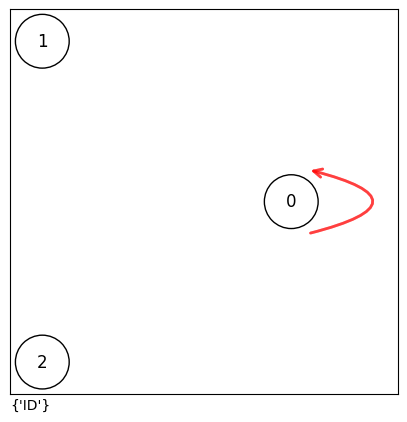

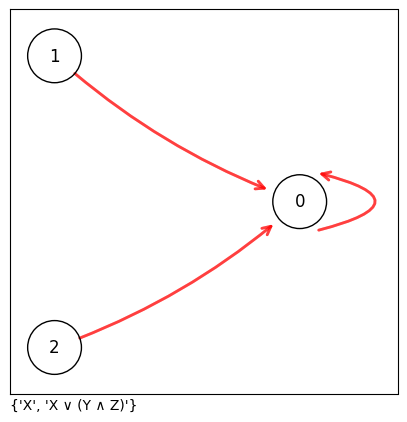

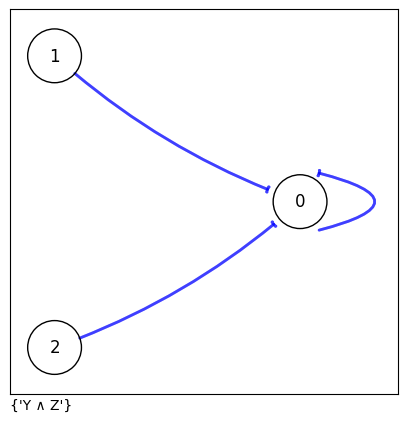

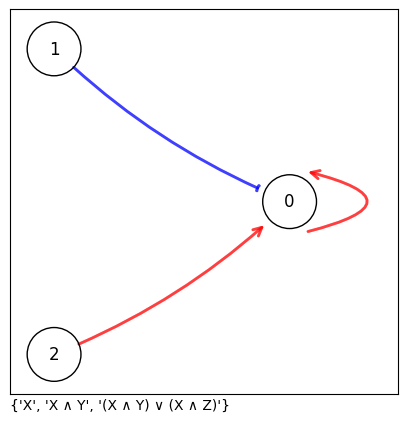

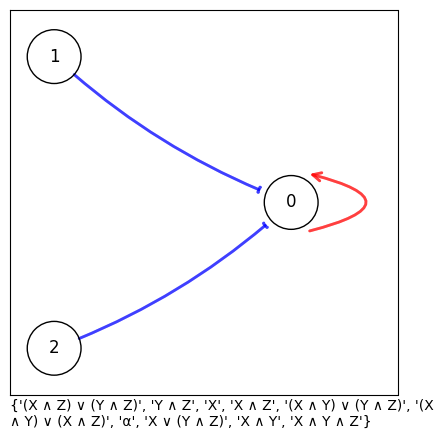

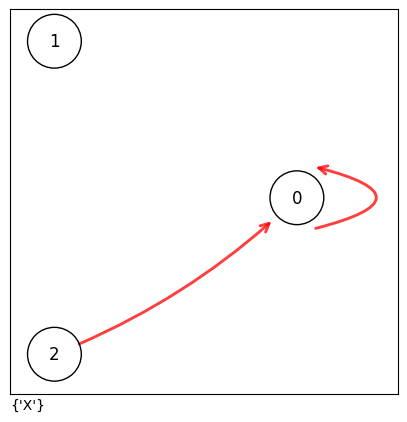

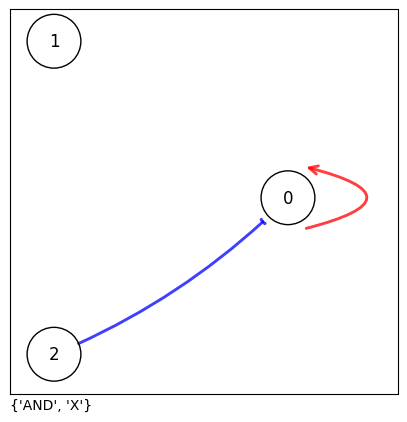

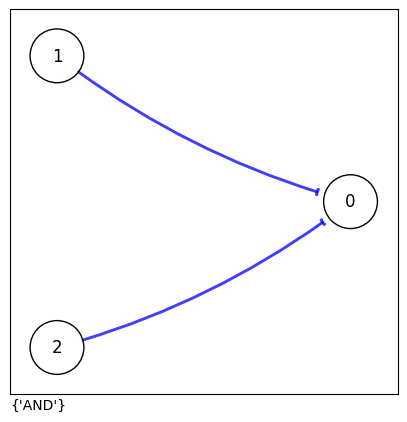

In [12]:
for idx, row in Wi.iterrows():
    W = row['W']
    A = row['A']
    fig, ax = mn.pl.network(A)
    ax.text(0, -0.01, str(W), transform=ax.transAxes, verticalalignment='top', wrap=True)